In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importing penguins dataset

penguins = pd.read_csv('~/110-F25/demos/palmer_penguins.csv')
penguins

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11/11/07,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11/11/07,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12/1/09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN


In [3]:
# dropping unneeded columns

cols_penguins = penguins[["Sex", "Culmen Length (mm)", "Culmen Depth (mm)", "Flipper Length (mm)", "Body Mass (g)"]]
cols_penguins

,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,MALE,39.1,18.7,181.0,3750.0
1,FEMALE,39.5,17.4,186.0,3800.0
2,FEMALE,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN,NaN
4,FEMALE,36.7,19.3,193.0,3450.0
...,...,...,...,...,...
339,NaN,NaN,NaN,NaN,NaN
340,FEMALE,46.8,14.3,215.0,4850.0
341,MALE,50.4,15.7,222.0,5750.0
342,FEMALE,45.2,14.8,212.0,5200.0


In [4]:
# dropping columns with null values

clean_penguins = cols_penguins.dropna()
clean_penguins

,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,MALE,39.1,18.7,181.0,3750.0
1,FEMALE,39.5,17.4,186.0,3800.0
2,FEMALE,40.3,18.0,195.0,3250.0
4,FEMALE,36.7,19.3,193.0,3450.0
5,MALE,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
338,FEMALE,47.2,13.7,214.0,4925.0
340,FEMALE,46.8,14.3,215.0,4850.0
341,MALE,50.4,15.7,222.0,5750.0
342,FEMALE,45.2,14.8,212.0,5200.0


In [5]:
# there is a row in the column "Sex" that has the value "." rather than "MALE" or "FEMALE" so we need to drop that row

clean_penguins = clean_penguins[clean_penguins["Sex"] != "."]
clean_penguins

,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,MALE,39.1,18.7,181.0,3750.0
1,FEMALE,39.5,17.4,186.0,3800.0
2,FEMALE,40.3,18.0,195.0,3250.0
4,FEMALE,36.7,19.3,193.0,3450.0
5,MALE,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
338,FEMALE,47.2,13.7,214.0,4925.0
340,FEMALE,46.8,14.3,215.0,4850.0
341,MALE,50.4,15.7,222.0,5750.0
342,FEMALE,45.2,14.8,212.0,5200.0


In [6]:
# changing "Sex" column into numerical data

is_F = (clean_penguins["Sex"] == "FEMALE")
clean_penguins["Sex"] = is_F.astype(int)
clean_penguins

/tmp/ipykernel_1836155/3998454854.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_penguins["Sex"] = is_F.astype(int)


,Sex,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g)
0,0,39.1,18.7,181.0,3750.0
1,1,39.5,17.4,186.0,3800.0
2,1,40.3,18.0,195.0,3250.0
4,1,36.7,19.3,193.0,3450.0
5,0,39.3,20.6,190.0,3650.0
...,...,...,...,...,...
338,1,47.2,13.7,214.0,4925.0
340,1,46.8,14.3,215.0,4850.0
341,0,50.4,15.7,222.0,5750.0
342,1,45.2,14.8,212.0,5200.0


In [7]:
# creating train and test sets

np.random.seed(420)

train_penguins = clean_penguins.sample(frac=0.8)
test_penguins = clean_penguins.drop(index=train_penguins.index)

print(train_penguins.shape, test_penguins.shape)

(266, 5) (67, 5)


In [8]:
# creating tables for the train and test sets to predict "Sex"

y_train_penguins = train_penguins["Sex"]
X_train_penguins = train_penguins.drop(columns=["Sex"])
print(X_train_penguins.shape, y_train_penguins.shape)

y_test_penguins = test_penguins["Sex"]
X_test_penguins = test_penguins.drop(columns=["Sex"])
print(X_test_penguins.shape, y_test_penguins.shape)

(266, 4) (266,)
(67, 4) (67,)


Score on train: 0.9135338345864662
Score on test: 0.8059701492537313


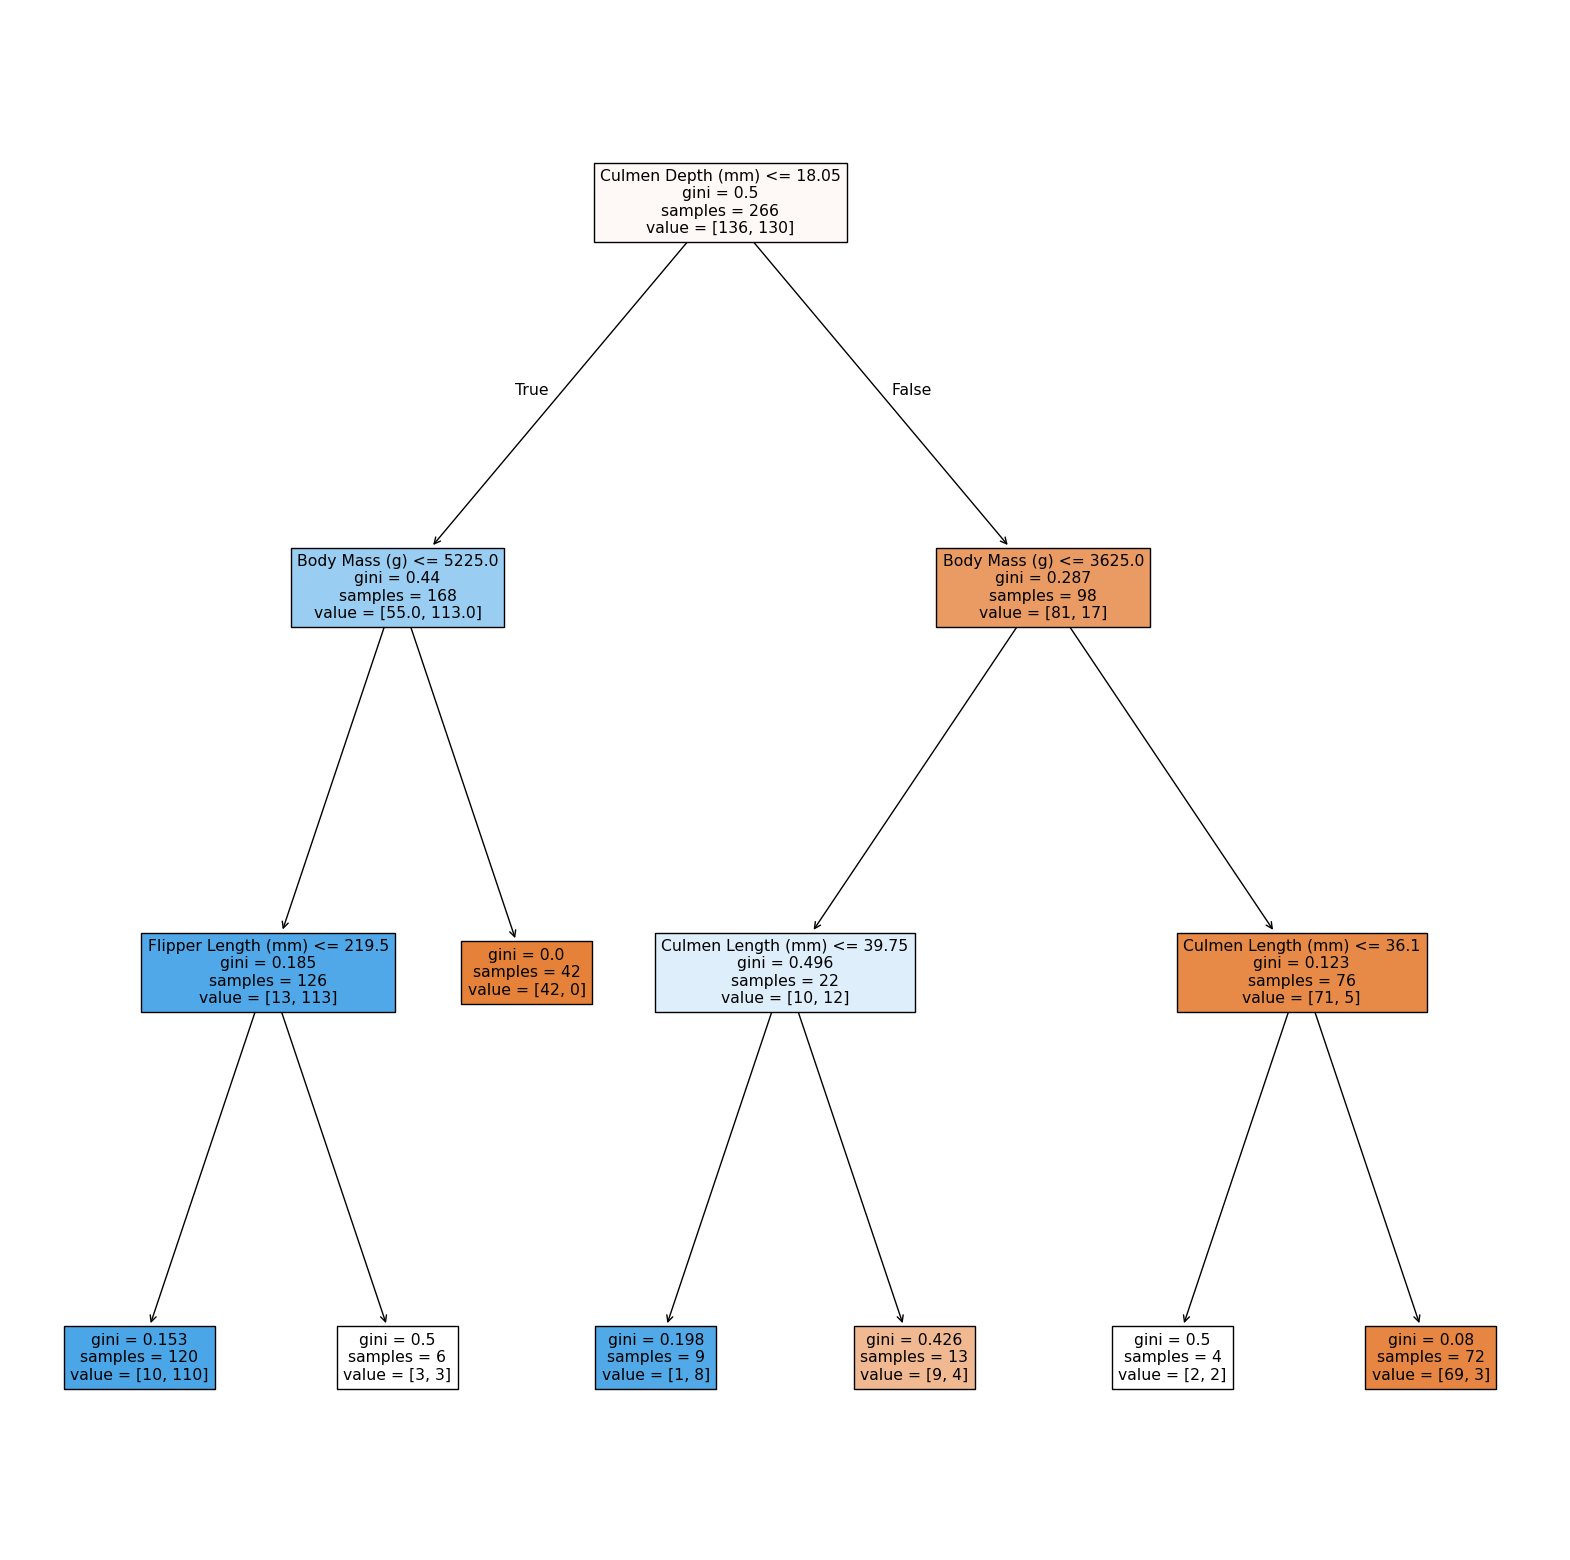

In [9]:
# using DecisionTreeClassifier to create a decision tree to use for prediction

from sklearn.tree import DecisionTreeClassifier, plot_tree

# we will begin by using max_depth of 3, and then find the "sweet spot" after

T = DecisionTreeClassifier(max_depth=3)
T.fit(X_train_penguins, y_train_penguins)

train_score = T.score(X_train_penguins, y_train_penguins)
test_score = T.score(X_test_penguins, y_test_penguins)

print('Score on train:', train_score)
print('Score on test:', test_score)

fig, ax = plt.subplots(1, figsize = (20, 20))
p = plot_tree(T, filled = True, feature_names = X_train_penguins.columns)

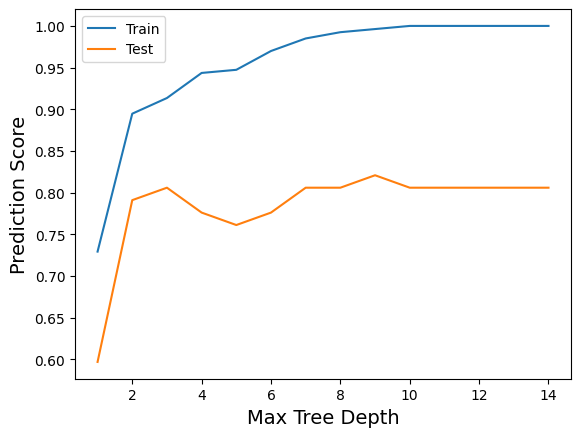

In [12]:
# finding the "sweet spot" for max_depth in the decision tree

train_scores=[]
test_scores=[]
r=range(1,15)
for i in r:

    T = DecisionTreeClassifier(max_depth=i)

    T.fit(X_train_penguins, y_train_penguins)
    train_scores.append(T.score(X_train_penguins, y_train_penguins))
    test_scores.append(T.score(X_test_penguins, y_test_penguins))
fig, ax = plt.subplots(1)
sns.lineplot(x=r,y=train_scores,label='Train')
sns.lineplot(x=r,y=test_scores,label='Test')
ax.set_ylabel('Prediction Score', fontsize=14)
ax.set_xlabel('Max Tree Depth', fontsize=14)
ax.legend()

Score on train: 0.9135338345864662
Score on test: 0.8059701492537313


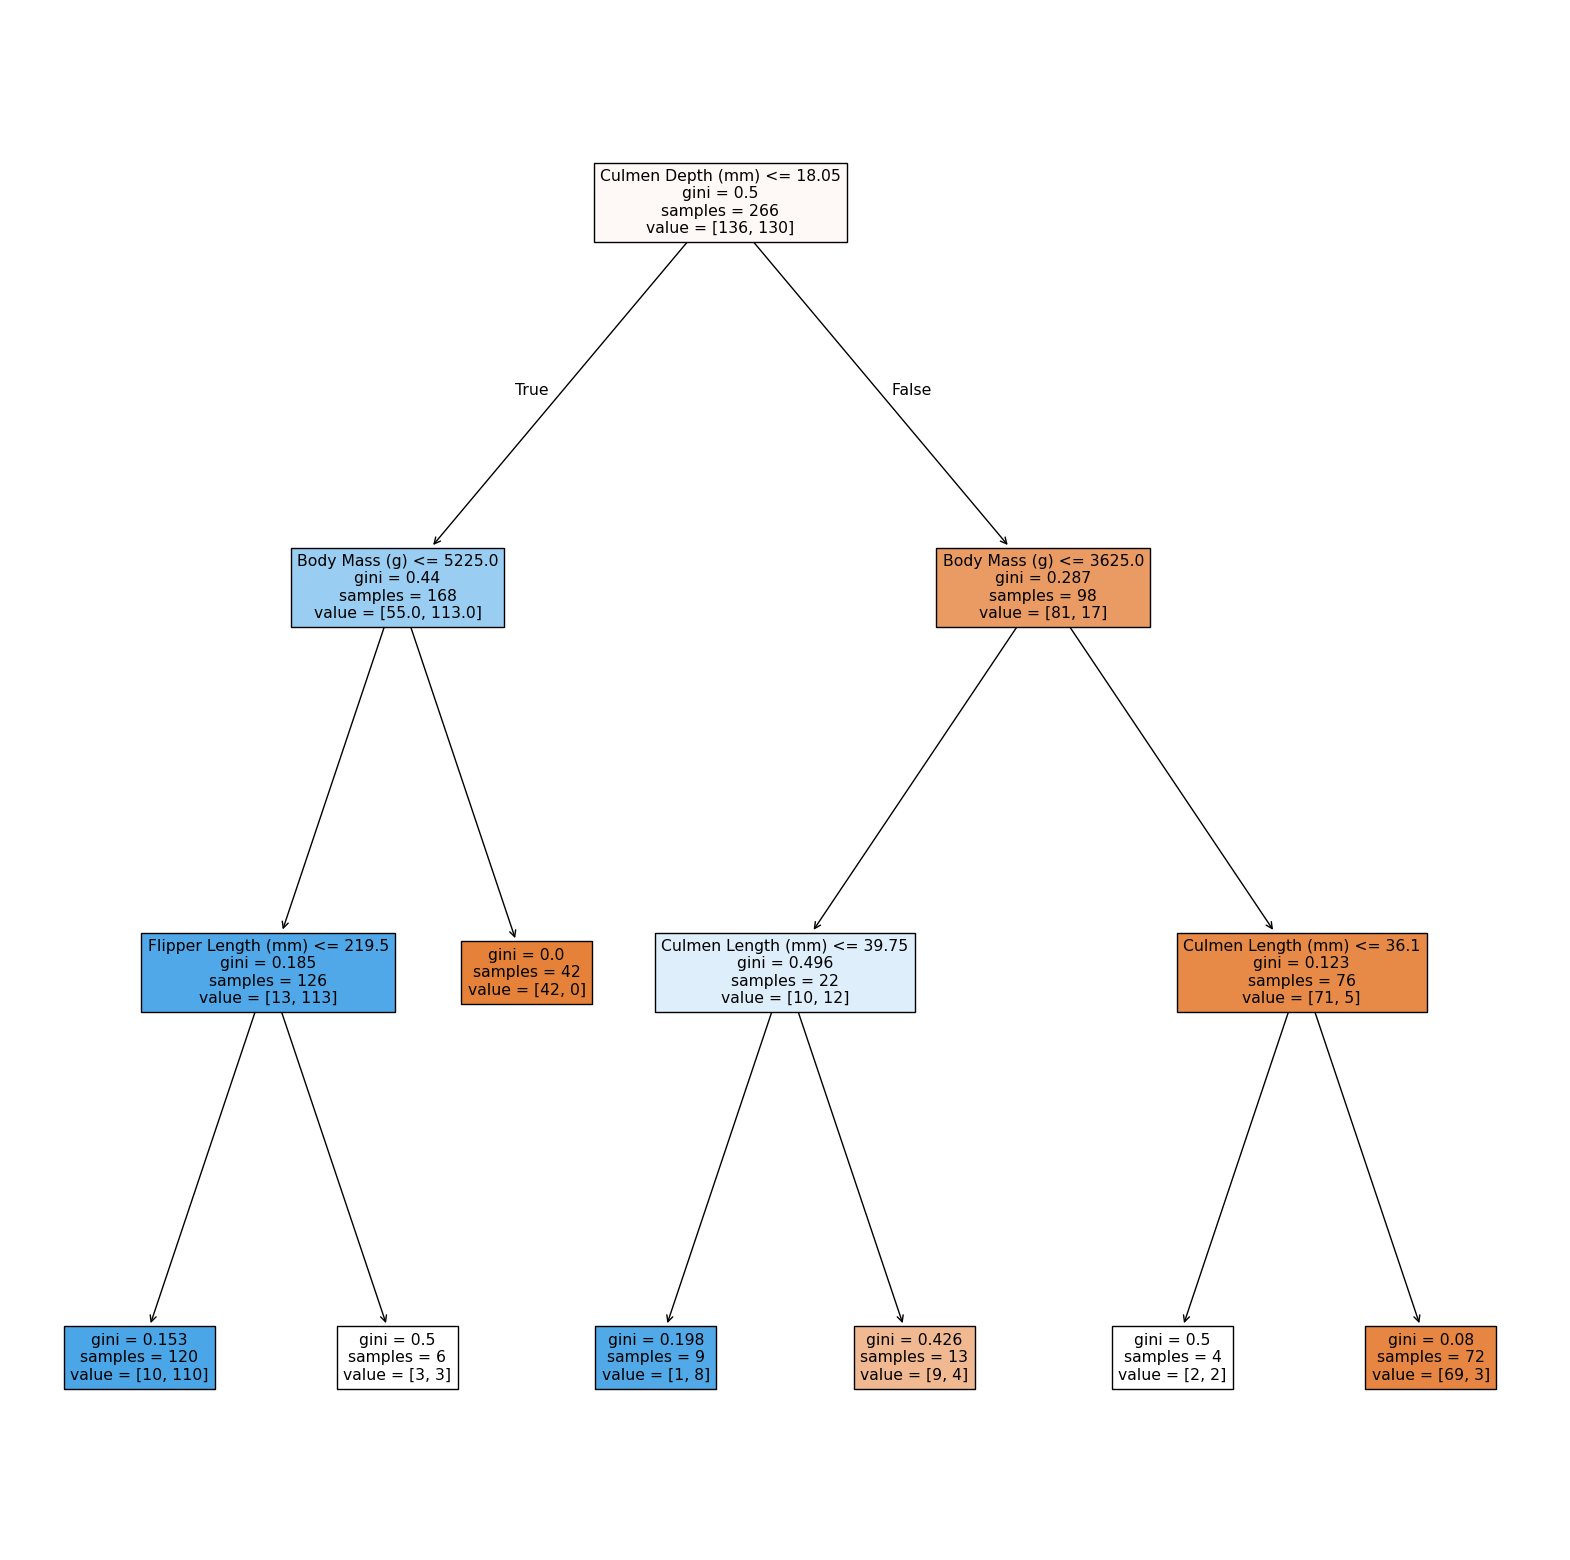

In [14]:
# from the plot, we can see that the test score doesn't increase significantly past max_depth of 3, 
# so we will use max_depth = 3 for the decision tree for the sake of readability and simplicity

T = DecisionTreeClassifier(max_depth=3)
T.fit(X_train_penguins, y_train_penguins)

train_score = T.score(X_train_penguins, y_train_penguins)
test_score = T.score(X_test_penguins, y_test_penguins)

print('Score on train:', train_score)
print('Score on test:', test_score)

fig, ax = plt.subplots(1, figsize = (20, 20))
p = plot_tree(T, filled = True, feature_names = X_train_penguins.columns)